<center><h1>Wendu_Liu_HW2</h1></center>
<br>
<br>

Name: Wendu Liu
<br>
Github Username: wenduliu-ops
<br>
USC ID: 8752-8093-81

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

Get the Cycle Power Plant Data Set

In [2]:
data = pd.read_excel(
    "Homework 2 Data/CCPP/Folds5x2_pp.xlsx",
    sheet_name=0
)

data.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [3]:
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])
print("Columns:", data.columns.tolist())


Number of rows: 9568
Number of columns: 5
Columns: ['AT', 'V', 'AP', 'RH', 'PE']


The dataset contains 9,568 rows and 5 columns. 
Each row represents one hourly observation from the power plant. 
The columns AT, V, AP, and RH are the predictor variables, and PE is the response variable representing the net hourly electrical energy output.

#### ii. pairwise scatterplots of all the varianbles

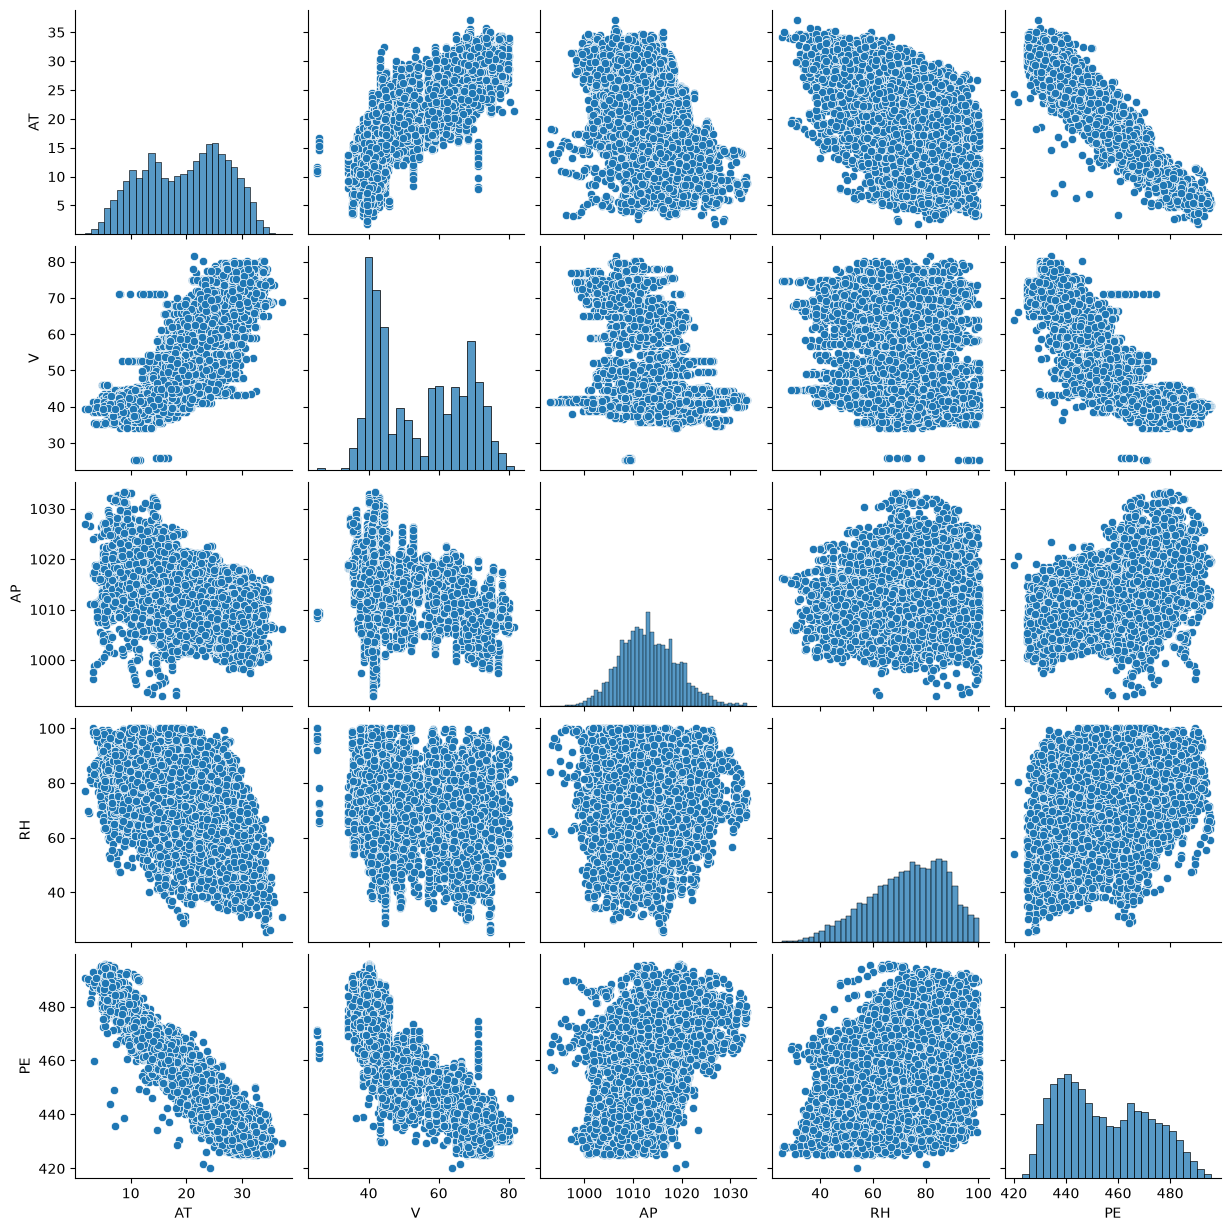

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(data)
plt.show()

From the pairwise scatterplots, PE decreases strongly as AT and V increase. 
AP and RH have weaker positive relationships with PE. AT and V are also positively related to each other. 
Overall, AT seems to have the strongest relationship with PE.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
summary = pd.DataFrame({
    "Mean": data.mean(),
    "Median": data.median(),
    "Range": data.max() - data.min(),
    "Q1": data.quantile(0.25),
    "Q3": data.quantile(0.75),
    "IQR": data.quantile(0.75) - data.quantile(0.25)
})

summary.round(2)

,Mean,Median,Range,Q1,Q3,IQR
AT,19.65,20.34,35.30,13.51,25.72,12.21
V,54.31,52.08,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,74.60,63.33,84.83,21.50
PE,454.37,451.55,75.50,439.75,468.43,28.68


The summary table shows the mean, median, range, first quartile, third quartile, and IQR for each variable.
PE and RH have the largest ranges, while AP has the smallest IQR.
The means and medians are fairly close for all variables, suggesting that the distributions are not extremely skewed.

### (c) Simple Linear Regression


 AT
Coefficient: -2.1713199585177962
p-value: 0.0
R-squared: 0.8989475964148236

 V
Coefficient: -1.168135126555711
p-value: 0.0
R-squared: 0.7565177870683979

 AP
Coefficient: 1.4898716733991122
p-value: 0.0
R-squared: 0.2687686564110676

 RH
Coefficient: 0.45565010226298
p-value: 0.0
R-squared: 0.151939440231176


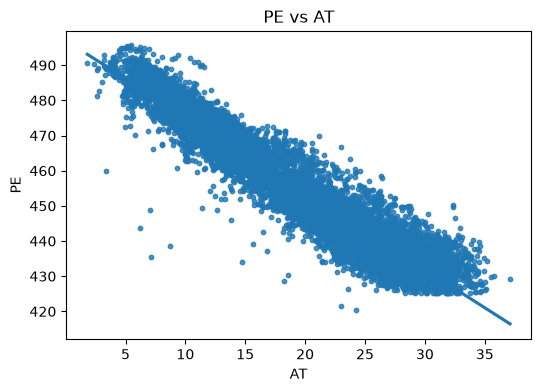

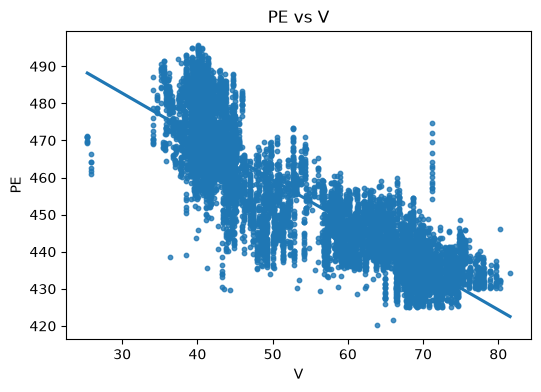

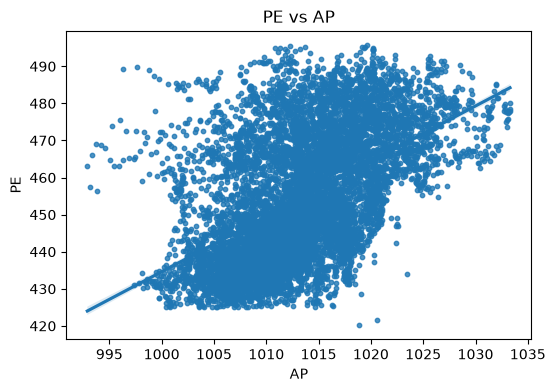

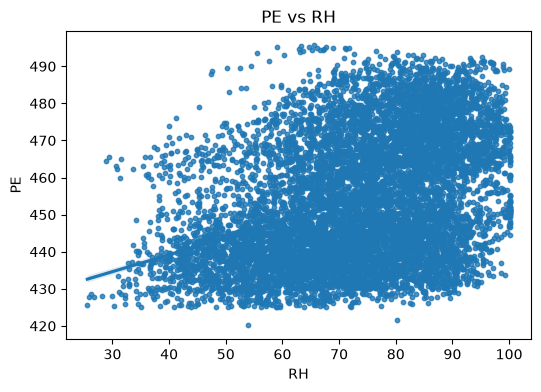

In [6]:

# 1(c) Simple Linear Regression

predictors = ["AT", "V", "AP", "RH"]

simple_models = {}

for predictor in predictors:
    model = smf.ols(f"PE ~ {predictor}", data=data).fit()
    simple_models[predictor] = model

    print("\n", predictor)
    print("Coefficient:", model.params[predictor])
    print("p-value:", model.pvalues[predictor])
    print("R-squared:", model.rsquared)


for predictor in predictors:
    plt.figure(figsize=(6, 4))

    sns.regplot(
        x=predictor,
        y="PE",
        data=data,
        scatter_kws={"s": 10}
    )

    plt.title(f"PE vs {predictor}")
    plt.xlabel(predictor)
    plt.ylabel("PE")
    plt.show()



All four predictors are statistically significant because their p-values are very small (less than 0.05).
AT and V have negative relationships with PE, while AP and RH have positive relationships with PE.
AT has the strongest linear relationship with PE with an R-squared of about 0.899.
V is the second strongest with an R-squared of about 0.757.
AP and RH have weaker linear relationships with PE, with R-squared values of about 0.269 and 0.152.
There are some possible outliers in the plots, but I would not remove them based only on visual inspection.



The regression plots show that AT and V have strong negative relationships with PE.
As AT and V increase, PE generally decreases.
AP has a positive relationship with PE, while RH has a weaker positive relationship with PE.
AT appears to have the strongest linear relationship with PE, followed by V.
There are a few possible outliers in the plots, but there is not enough evidence to remove them based only on visual inspection.
Therefore, I would keep all observations unless further diagnostic analysis shows that some points are highly influential.

### (d) Multiple Regression

In [7]:
multiple_model = smf.ols(
    "PE ~ AT + V + AP + RH",
    data=data
).fit()

print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:18:34   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

The multiple linear regression model has an R-squared value of 0.929,
which means that AT, V, AP, and RH together explain about 92.9% of the variation in PE.
AT, V, AP, and RH all have p-values less than 0.05, so we reject H0: beta_j = 0 for all four predictors.
AT and V have negative coefficients, AP has a positive coefficient, and RH has a negative coefficient.
Therefore, all four predictors are statistically significant in the multiple regression model.

### (e) 1c Compare to 1d

    Simple Regression  Multiple Regression
AT          -2.171320            -1.977513
V           -1.168135            -0.233916
AP           1.489872             0.062083
RH           0.455650            -0.158054


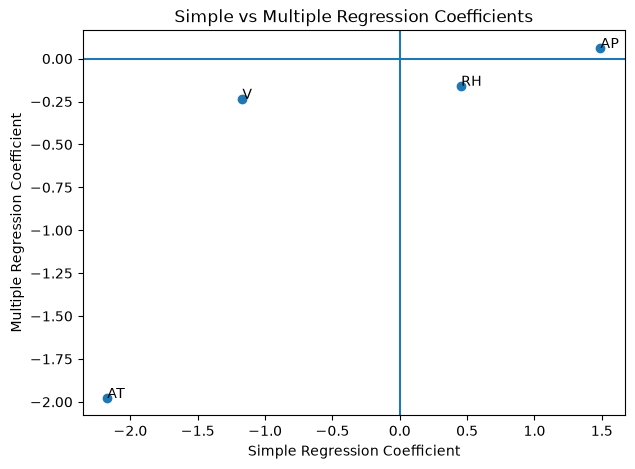

In [8]:
simple_coefficients = {}

for predictor in predictors:
    simple_coefficients[predictor] = simple_models[predictor].params[predictor]

multiple_coefficients = multiple_model.params[predictors]

coef_compare = pd.DataFrame({
    "Simple Regression": pd.Series(simple_coefficients),
    "Multiple Regression": multiple_coefficients
})

print(coef_compare)

plt.figure(figsize=(7, 5))

plt.scatter(
    coef_compare["Simple Regression"],
    coef_compare["Multiple Regression"]
)

for predictor in predictors:
    plt.annotate(
        predictor,
        (
            coef_compare.loc[predictor, "Simple Regression"],
            coef_compare.loc[predictor, "Multiple Regression"]
        )
    )

plt.xlabel("Simple Regression Coefficient")
plt.ylabel("Multiple Regression Coefficient")
plt.title("Simple vs Multiple Regression Coefficients")

plt.axhline(0)
plt.axvline(0)

plt.show()

The regression coefficients change noticeably between the simple and multiple regression models.
AT remains strongly negative, changing from -2.1713 to -1.9775.
V also remains negative, but its coefficient decreases substantially from -1.1681 to -0.2339.
AP remains positive, but its coefficient decreases from 1.4899 to 0.0621.
RH changes from a positive coefficient of 0.4557 in simple regression to a negative coefficient of -0.1581 in multiple regression.
These differences suggest that the predictors are correlated with each other, so controlling for the other predictors changes their estimated effects on PE.

### (f) Nonlinear Association

In [9]:
results = []

for predictor in ["AT", "V", "AP", "RH"]:
    temp = data.copy()
    temp["X"] = temp[predictor] - temp[predictor].mean()

    model = smf.ols(
        "PE ~ X + I(X**2) + I(X**3)",
        data=temp
    ).fit()

    results.append({
        "Predictor": predictor,
        "R-squared": model.rsquared,
        "Linear p-value": model.pvalues.iloc[1],
        "Quadratic p-value": model.pvalues.iloc[2],
        "Cubic p-value": model.pvalues.iloc[3]
    })

nonlinear_results = pd.DataFrame(results)
nonlinear_results


,Predictor,R-squared,Linear p-value,Quadratic p-value,Cubic p-value
0,AT,0.911883,0.000000e+00,3.311808e-231,3.652185e-110
1,V,0.775022,0.000000e+00,8.977010e-131,1.373489e-02
2,AP,0.297543,0.000000e+00,2.192722e-46,2.123338e-67
3,RH,0.153743,9.648727e-152,1.013949e-01,1.440279e-05


There is evidence of nonlinear association between all four predictors and PE.
For AT, both the quadratic and cubic terms are statistically significant because their p-values are less than 0.05.
For V, both the quadratic and cubic terms are also statistically significant.
For AP, both the quadratic and cubic terms are statistically significant.
For RH, the quadratic term is not significant because its p-value is about 0.101, but the cubic term is significant.
Therefore, AT, V, AP, and RH all show evidence of nonlinear relationships with PE.

### (g) Interactions of Predictors

In [10]:
interaction_model = smf.ols(
    "PE ~ AT + V + AP + RH + AT:V + AT:AP + AT:RH + V:AP + V:RH + AP:RH",
    data=data
).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:18:34   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

The full interaction model has an R-squared value of 0.936.
AT:V, AT:RH, V:AP, and AP:RH are statistically significant because their p-values are less than 0.05.
AT:AP and V:RH are not statistically significant because their p-values are greater than 0.05.
Therefore, there is evidence that several pairwise interactions between predictors are associated with PE.
In particular, the effect of one predictor on PE can depend on the value of another predictor for these significant interaction terms.

### (h) Improvement

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

train_data, test_data = train_test_split(
    data,
    test_size=0.30,
    random_state=42
)

print("Training observations:", len(train_data))
print("Testing observations:", len(test_data))
##full model
linear_model = smf.ols(
    "PE ~ AT + V + AP + RH",
    data=train_data
).fit()

train_pred = linear_model.predict(train_data)
test_pred = linear_model.predict(test_data)

linear_train_mse = mean_squared_error(
    train_data["PE"],
    train_pred
)

linear_test_mse = mean_squared_error(
    test_data["PE"],
    test_pred
)

print("Linear Regression Train MSE:", linear_train_mse)
print("Linear Regression Test MSE:", linear_test_mse)

full_model = smf.ols(
    """
    PE ~ AT + V + AP + RH
    + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)
    + AT:V + AT:AP + AT:RH
    + V:AP + V:RH + AP:RH
    """,
    data=train_data
).fit()

print(full_model.summary())



full_model.pvalues.sort_values(ascending=False)

Training observations: 6697
Testing observations: 2871
Linear Regression Train MSE: 20.580839725738695
Linear Regression Test MSE: 21.239856938225554
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:18:34   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      

V:RH          8.673824e-01
I(V ** 2)     6.998020e-01
V:AP          3.811800e-01
V             2.671816e-01
AT:AP         1.966307e-01
AT            4.460633e-02
AT:V          3.195237e-03
AT:RH         3.056335e-03
AP:RH         2.937919e-04
RH            1.429286e-04
I(AT ** 2)    5.017196e-07
Intercept     8.518151e-08
AP            9.534685e-09
I(AP ** 2)    8.522142e-09
I(RH ** 2)    1.395087e-09
dtype: float64

V:RH       p = 0.867
V^2        p = 0.700
V:AP       p = 0.381
AT:AP      p = 0.197
they are not significant, so delete these terms

In [12]:
## reduced model
reduced_model = smf.ols(
    """
    PE ~ AT + V + AP + RH
    + I(AT**2) + I(AP**2) + I(RH**2)
    + AT:V + AT:RH + AP:RH
    """,
    data=train_data
).fit()

print(reduced_model.summary())


reduced_train_pred = reduced_model.predict(train_data)
reduced_test_pred = reduced_model.predict(test_data)

reduced_train_mse = mean_squared_error(
    train_data["PE"],
    reduced_train_pred
)

reduced_test_mse = mean_squared_error(
    test_data["PE"],
    reduced_test_pred
)

print("Linear Regression Train MSE:", linear_train_mse)
print("Linear Regression Test MSE:", linear_test_mse)

print("Reduced Nonlinear/Interaction Train MSE:", reduced_train_mse)
print("Reduced Nonlinear/Interaction Test MSE:", reduced_test_mse)


                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                 1.017e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:18:34   Log-Likelihood:                -19166.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6686   BIC:                         3.843e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.046e+04   1091.512     -9.581      0.0

The data was randomly split into 70% training data and 30% testing data.
The multiple linear regression model has a training MSE of 20.5808 and a test MSE of 21.2399.
After including significant quadratic and interaction terms, the reduced model has a training MSE of 17.9178 and a test MSE of 18.6943.
The reduced nonlinear/interaction model has lower training and test MSEs than the original linear regression model.
Therefore, including nonlinear and interaction terms improves the predictive performance of the model.

### (i) KNN

Best k for raw features: 5
Best raw train MSE: 10.600768887561596
Best raw test MSE: 15.726819842563568
Best k for normalized features: 4
Best normalized train MSE: 8.591432839331045
Best normalized test MSE: 14.305669422675024


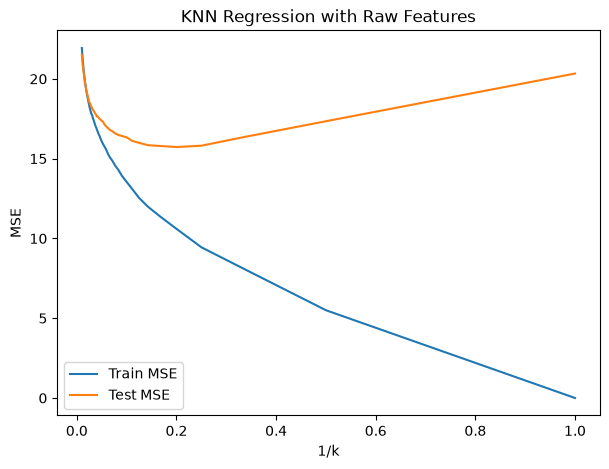

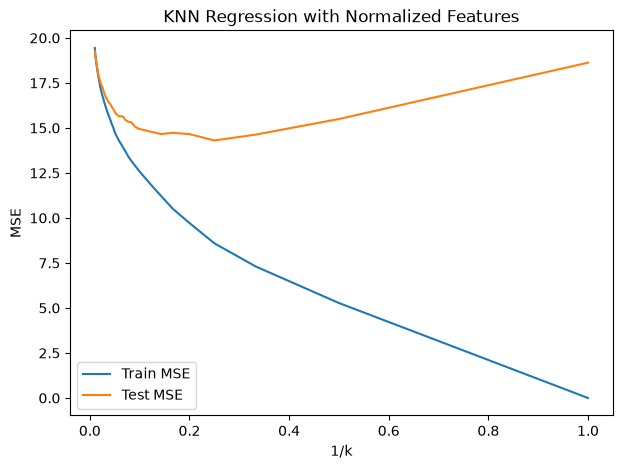

In [13]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

X_train = train_data[["AT", "V", "AP", "RH"]]
y_train = train_data["PE"]

X_test = test_data[["AT", "V", "AP", "RH"]]
y_test = test_data["PE"]

k_values = range(1, 101)

raw_train_mse = []
raw_test_mse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)

    raw_train_mse.append(mean_squared_error(y_train, train_pred))
    raw_test_mse.append(mean_squared_error(y_test, test_pred))

best_raw_k = np.argmin(raw_test_mse) + 1

print("Best k for raw features:", best_raw_k)
print("Best raw train MSE:", raw_train_mse[best_raw_k - 1])
print("Best raw test MSE:", raw_test_mse[best_raw_k - 1])


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaled_train_mse = []
scaled_test_mse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    train_pred = knn.predict(X_train_scaled)
    test_pred = knn.predict(X_test_scaled)

    scaled_train_mse.append(mean_squared_error(y_train, train_pred))
    scaled_test_mse.append(mean_squared_error(y_test, test_pred))

best_scaled_k = np.argmin(scaled_test_mse) + 1

print("Best k for normalized features:", best_scaled_k)
print("Best normalized train MSE:", scaled_train_mse[best_scaled_k - 1])
print("Best normalized test MSE:", scaled_test_mse[best_scaled_k - 1])


inverse_k = 1 / np.array(list(k_values))

plt.figure(figsize=(7, 5))

plt.plot(inverse_k, raw_train_mse, label="Train MSE")
plt.plot(inverse_k, raw_test_mse, label="Test MSE")

plt.xlabel("1/k")
plt.ylabel("MSE")
plt.title("KNN Regression with Raw Features")
plt.legend()
plt.show()


plt.figure(figsize=(7, 5))

plt.plot(inverse_k, scaled_train_mse, label="Train MSE")
plt.plot(inverse_k, scaled_test_mse, label="Test MSE")

plt.xlabel("1/k")
plt.ylabel("MSE")
plt.title("KNN Regression with Normalized Features")
plt.legend()
plt.show()

For the raw features, the best value of k is 5.
At k = 5, the training MSE is 10.6008 and the test MSE is 15.7268.
For the normalized features, the best value of k is 4.
At k = 4, the training MSE is 8.5914 and the test MSE is 14.3057.
The normalized KNN model performs better because it has a lower test MSE than the KNN model using raw features.
Normalization improves KNN because KNN is distance-based and the predictors are measured on different scales.

### (j ) Compare KNN and Linear

The reduced nonlinear/interaction regression model has a test MSE of 18.6943.
The best KNN model using raw features has a test MSE of 15.7268 with k = 5.
The best KNN model using normalized features has a test MSE of 14.3057 with k = 4.
Therefore, the normalized KNN model has the lowest test MSE and performs better on the test data.
This suggests that KNN can capture relationships in the data that are not fully represented by the regression model.
Normalization also improves KNN performance because KNN is based on distances between observations.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

A flexible method would likely perform better because n is very large and p is small.
With a large sample size, the model has enough data to fit more complex relationships without overfitting too much.


### (b) The number of predictors p is extremely large, and the number of observations n is small.

A flexible method would likely perform worse because p is very large and n is small.
This makes overfitting more likely, so an inflexible method would usually be better.

### (c) The relationship between the predictors and response is highly non-linear.

A flexible method would likely perform better because the relationship is highly nonlinear.
A flexible model can better capture the complex pattern between the predictors and the response.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

A flexible method would likely perform worse because the error variance is very high.
The model may fit the noise instead of the true relationship, which can lead to overfitting.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

The Euclidean distances from the test point (0, 0, 0) are:

1. sqrt(0^2 + 3^2 + 0^2) = 3
2. sqrt(2^2 + 0^2 + 0^2) = 2
3. sqrt(0^2 + 1^2 + 3^2) = sqrt(10) ≈ 3.16
4. sqrt(0^2 + 1^2 + 2^2) = sqrt(5) ≈ 2.24
5. sqrt((-1)^2 + 0^2 + 1^2) = sqrt(2) ≈ 1.41
6. sqrt(1^2 + 1^2 + 1^2) = sqrt(3) ≈ 1.73

### (b) What is our prediction with K = 1? Why?

For K = 1, the prediction is **Green** because observation 5 is the closest point and its response is Green.


### (c) What is our prediction with K = 3? Why?

For K = 3, the prediction is **Red**. The three nearest neighbors are observations 5, 6, and 2, with responses Green, Red, and Red. Therefore, Red is the majority class.


### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

A small value of K would be better because a small K gives a more flexible decision boundary. This is more suitable when the true decision boundary is highly nonlinear.